In [1]:
from pathlib import Path
import sys
import torch

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from hyperparamsearch.instancepipeline import get_data_loaders
from hyperparamsearch.instancetrainarti2 import FlexibleEarthquakeCNN, evaluate_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = PROJECT_ROOT / "hyperparamsearch" / "data" / "best_hyperparameter_model.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

architecture = checkpoint["architecture"]

if architecture == "32_5_512_128":
    initial_filters = 32
    n_layers = 5
    fc_size = 512
    fc_size2 = 128
else:
    initial_filters = 16
    n_layers = 6
    fc_size = 512
    fc_size2 = 128

n_filters = []

for i in range(n_layers):
    n_filters.append(min(initial_filters * (2 ** i), 512))

model = FlexibleEarthquakeCNN(
    n_layers=n_layers,
    n_filters=n_filters,
    kernel_size=5,
    dropout_rate=checkpoint["dropout_rate"],
    fc_size=fc_size,
    fc_size2=fc_size2,
    use_batchnorm=False
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

FlexibleEarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_siz

In [2]:
import torch
import numpy as np
import pandas as pd

train_loader, val_loader, test_loader = get_data_loaders()
all_predictions = []
all_targets = []
model.eval()

with torch.no_grad():
    for waveforms,magnitudes in val_loader:
        waveforms,magnitudes = waveforms.to(device), magnitudes.to(device)
        predictions = model(waveforms).squeeze(-1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())
results = pd.DataFrame({
    "true_magnitude": np.array(all_targets),
    "predicted_magnitude": np.array(all_predictions)
})




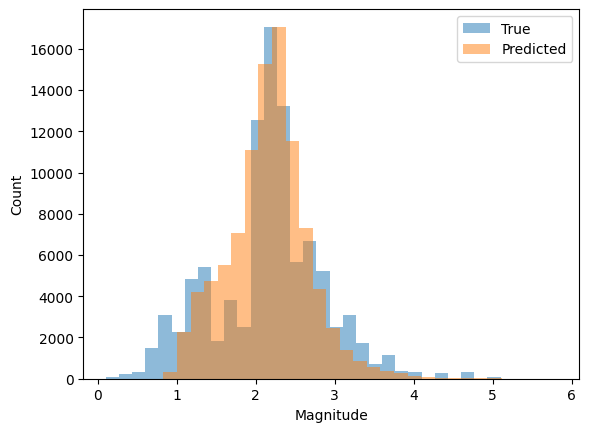

In [3]:
import matplotlib.pyplot as plt

plt.hist(results["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

In [4]:
print(results.describe())

       true_magnitude  predicted_magnitude
count    96993.000000         96993.000000
mean         2.144556             2.162011
std          0.696878             0.512239
min          0.100000             0.658644
25%          1.800000             1.864726
50%          2.200000             2.186028
75%          2.500000             2.443042
max          5.100000             5.811067


In [5]:
mask = (results["true_magnitude"] >= 0) & (results["true_magnitude"] < 1)

mae_0_1 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_0_1)

0.73044014


In [6]:
mask = (results["true_magnitude"] >= 1) & (results["true_magnitude"] < 2)

mae_1_2 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_1_2 )

0.39382115


In [7]:
mask = (results["true_magnitude"] >= 2) & (results["true_magnitude"] < 3)

mae_2_3 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_2_3 )

0.27157187


In [8]:
mask = (results["true_magnitude"] >= 3) & (results["true_magnitude"] < 4)

mae_3_4 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_3_4 )

0.5812421


In [9]:
mask = (results["true_magnitude"] >= 4) & (results["true_magnitude"] < 5)

mae_4_5 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_4_5 )

1.0276273


In [10]:
mask = (results["true_magnitude"] >= 5) & (results["true_magnitude"] < 6)

mae_5_6 = (
    results.loc[mask, "true_magnitude"]
    - results.loc[mask, "predicted_magnitude"]
).abs().mean()

print(mae_5_6 )

1.5286956


In [11]:
maebins = [mae_0_1,mae_1_2,mae_2_3,mae_3_4,mae_4_5,mae_5_6]


In [12]:

mae_df = pd.DataFrame({
    "bin": ["0-1", "1-2", "2-3", "3-4", "4-5", "5-6"],
    "MAE": maebins
})

print(mae_df)

   bin       MAE
0  0-1  0.730440
1  1-2  0.393821
2  2-3  0.271572
3  3-4  0.581242
4  4-5  1.027627
5  5-6  1.528696


In [13]:
results["error"] = (
    results["predicted_magnitude"] -
    results["true_magnitude"]
)
for low in range(6):
    mask = (
        (results["true_magnitude"] >= low) &
        (results["true_magnitude"] < low + 1)
    )

    print(
        f"{low}-{low+1}",
        "count =", mask.sum(),
        "MAE =", results.loc[mask, "error"].abs().mean(),
        "bias =", results.loc[mask, "error"].mean()
    )

0-1 count = 5190 MAE = 0.73044014 bias = 0.7303796
1-2 count = 20718 MAE = 0.39382115 bias = 0.33754238
2-3 count = 60450 MAE = 0.27157187 bias = -0.052426882
3-4 count = 9608 MAE = 0.5812421 bias = -0.50648403
4-5 count = 936 MAE = 1.0276273 bias = -0.98244154
5-6 count = 91 MAE = 1.5286956 bias = -1.4925169


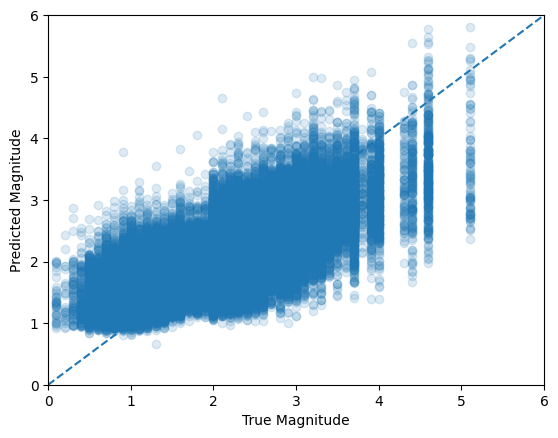

In [14]:
plt.scatter(
    results["true_magnitude"],
    results["predicted_magnitude"],
    alpha=0.15
)

plt.plot([0, 6], [0, 6], "--")

plt.xlabel("True Magnitude")
plt.ylabel("Predicted Magnitude")
plt.xlim(0, 6)
plt.ylim(0, 6)
plt.show()

In [15]:
print(results.count())

true_magnitude         96993
predicted_magnitude    96993
error                  96993
dtype: int64
